# 데이터 재구성

`processed/body/` 안에 섞여 있는 파일을 아래 규칙으로 정리합니다.

| 대상 | 처리 |
|------|------|
| `wings_*` | `processed/wings/` 로 이동 |
| `tail_*` | `processed/tail/` 로 이동 |
| `bodies_zombie_*` | 삭제 |
| `bodies_skeleton_*` | 삭제 |
| 나머지 | `processed/body/` 유지 |

## 1. 현재 상태 확인

In [13]:
from pathlib import Path
from collections import Counter
import shutil
import matplotlib.pyplot as plt
import numpy as np

PROCESSED  = Path('dataset/processed')
BODY_DIR   = PROCESSED / 'body'
WINGS_DIR  = PROCESSED / 'wings'
TAIL_DIR   = PROCESSED / 'tail'

files = list(BODY_DIR.glob('*.png'))
print(f'processed/body 총 파일: {len(files):,}개\n')

# 첫 번째 파트로 서브타입 분류
subtypes = Counter(f.stem.split('_')[0] for f in files)
for k, v in subtypes.most_common():
    print(f'  {k:<15s}  {v:>7,}개')

processed/body 총 파일: 199,615개

  wings            100,264개
  tail              93,593개
  wound              2,528개
  bodies             1,992개
  prosthesis           532개
  child                106개
  male                 106개
  female               106개
  muscular             106개
  teen                 106개
  pregnant             106개
  wheelchair            70개


In [14]:
# 이동/삭제 대상 수 집계
to_wings    = [f for f in files if f.stem.startswith('wings_')]
to_tail     = [f for f in files if f.stem.startswith('tail_')]
to_delete   = [f for f in files if f.stem.startswith('bodies_zombie_')
                               or  f.stem.startswith('bodies_skeleton_')]
to_keep     = [f for f in files
               if not f.stem.startswith('wings_')
               and not f.stem.startswith('tail_')
               and not f.stem.startswith('bodies_zombie_')
               and not f.stem.startswith('bodies_skeleton_')]

print(f'wings 로 이동   : {len(to_wings):>7,}개')
print(f'tail  로 이동   : {len(to_tail):>7,}개')
print(f'삭제 (zombie)   : {len([f for f in to_delete if "zombie" in f.stem]):>7,}개')
print(f'삭제 (skeleton) : {len([f for f in to_delete if "skeleton" in f.stem]):>7,}개')
print(f'body 유지       : {len(to_keep):>7,}개')
print(f'---')
print(f'합계            : {len(to_wings)+len(to_tail)+len(to_delete)+len(to_keep):>7,}개')

wings 로 이동   : 100,264개
tail  로 이동   :  93,593개
삭제 (zombie)   :     178개
삭제 (skeleton) :     178개
body 유지       :   5,402개
---
합계            : 199,615개


/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/296747403.py:29: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/296747403.py:29: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/296747403.py:29: UserWarning: Glyph 49325 (\N{HANGUL SYLLABLE SAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/296747403.py:29: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/296747403.py:29: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50

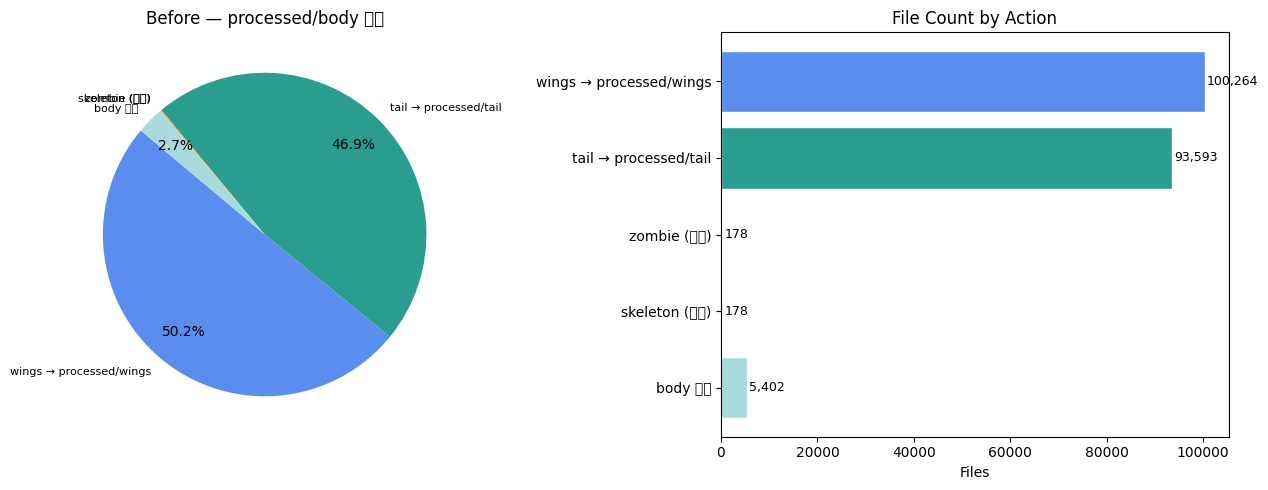

In [15]:
# 재구성 전 분포 시각화
labels  = ['wings → processed/wings', 'tail → processed/tail',
           'zombie (삭제)', 'skeleton (삭제)', 'body 유지']
counts  = [len(to_wings), len(to_tail),
           len([f for f in to_delete if 'zombie'   in f.stem]),
           len([f for f in to_delete if 'skeleton' in f.stem]),
           len(to_keep)]
colors  = ['#5b8dee', '#2a9d8f', '#e76f51', '#e9c46a', '#a8dadc']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 파이차트
wedges, texts, autotexts = ax1.pie(
    counts, labels=labels, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=140, pctdistance=0.78,
)
for t in texts: t.set_fontsize(8)
ax1.set_title('Before — processed/body 구성', fontsize=12)

# 막대그래프
bars = ax2.barh(labels[::-1], counts[::-1], color=colors[::-1], edgecolor='white')
ax2.set_title('File Count by Action', fontsize=12)
ax2.set_xlabel('Files')
for bar, v in zip(bars, counts[::-1]):
    ax2.text(v + 500, bar.get_y() + bar.get_height()/2,
             f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 2. 샘플 미리보기

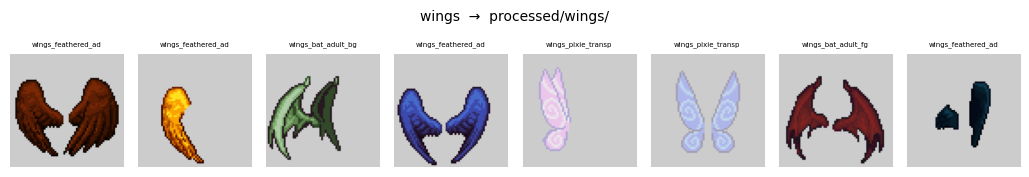

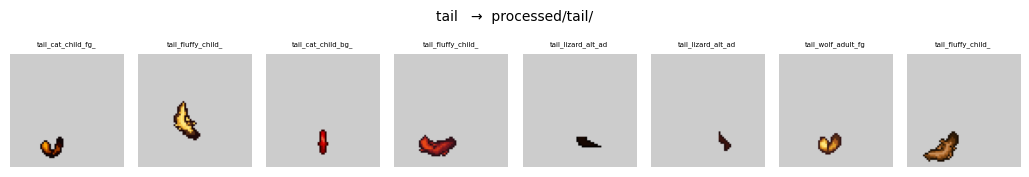

/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/1357068574.py:18: UserWarning: Glyph 49325 (\N{HANGUL SYLLABLE SAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/1357068574.py:18: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


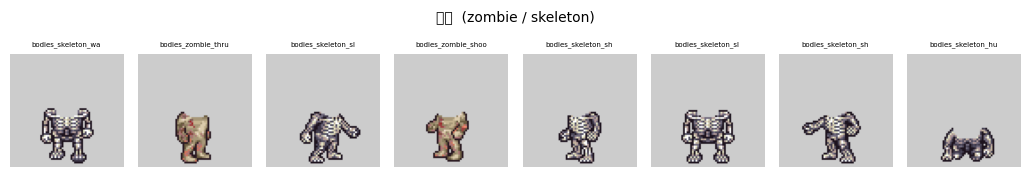

/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/1357068574.py:18: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_50048/1357068574.py:18: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


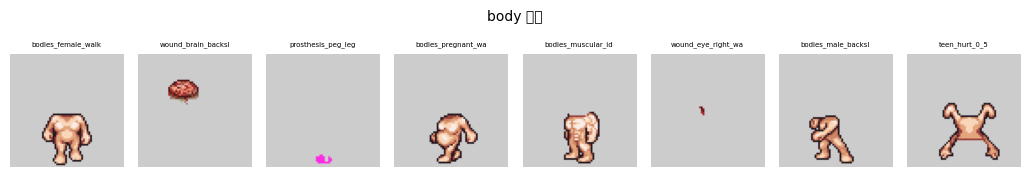

In [16]:
import random
from PIL import Image

random.seed(42)

def show_samples(file_list, title, n=8, bg=(0.8, 0.8, 0.8)):
    picks = random.sample(file_list, min(n, len(file_list)))
    fig, axes = plt.subplots(1, len(picks), figsize=(len(picks) * 1.3, 1.8))
    if len(picks) == 1: axes = [axes]
    for ax, p in zip(axes, picks):
        img  = Image.open(p)
        base = Image.new('RGBA', img.size, (int(bg[0]*255),)*3 + (255,))
        base.paste(img, mask=img.split()[3])
        ax.imshow(base)
        ax.set_title(p.stem[:18], fontsize=5)
        ax.axis('off')
    plt.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

show_samples(to_wings,  'wings  →  processed/wings/')
show_samples(to_tail,   'tail   →  processed/tail/')
show_samples(to_delete, '삭제  (zombie / skeleton)')
show_samples(to_keep,   'body 유지')

## 3. 재구성 실행

In [17]:
# 대상 디렉토리 생성
WINGS_DIR.mkdir(parents=True, exist_ok=True)
TAIL_DIR.mkdir(parents=True,  exist_ok=True)

# wings 이동
for f in to_wings:
    f.rename(WINGS_DIR / f.name)
print(f'wings 이동 완료: {len(to_wings):,}개 → {WINGS_DIR}')

# tail 이동
for f in to_tail:
    f.rename(TAIL_DIR / f.name)
print(f'tail  이동 완료: {len(to_tail):,}개 → {TAIL_DIR}')

# zombie / skeleton 삭제
for f in to_delete:
    f.unlink()
print(f'삭제  완료      : {len(to_delete):,}개 (zombie + skeleton)')

wings 이동 완료: 100,264개 → dataset/processed/wings
tail  이동 완료: 93,593개 → dataset/processed/tail
삭제  완료      : 356개 (zombie + skeleton)


## 4. 재구성 결과 확인

In [18]:
# 재구성 후 각 디렉토리 파일 수
result = {}
for cat_dir in sorted(PROCESSED.iterdir()):
    if cat_dir.is_dir():
        cnt = sum(1 for _ in cat_dir.rglob('*.png'))
        result[cat_dir.name] = cnt

total = sum(result.values())
print(f'전체 프레임: {total:,}개\n')
for cat, cnt in sorted(result.items(), key=lambda x: -x[1]):
    print(f'  {cat:<12s}  {cnt:>9,}개')

전체 프레임: 2,852,034개

  hat             503,299개
  facial          351,280개
  feet            301,302개
  torso           295,414개
  head            280,548개
  shield          277,111개
  legs            242,177개
  neck            150,356개
  wings           100,264개
  tail             93,593개
  hair             67,894개
  eyes             56,794개
  dress            52,411개
  weapon           33,543개
  backpack         22,880개
  shoulders         5,972개
  body              5,402개
  beards            3,716개
  arms              2,956개
  wound             2,528개
  cape                842개
  tools               758개
  prosthesis          532개
  shadow              214개
  quiver              178개
  wheelchair           70개


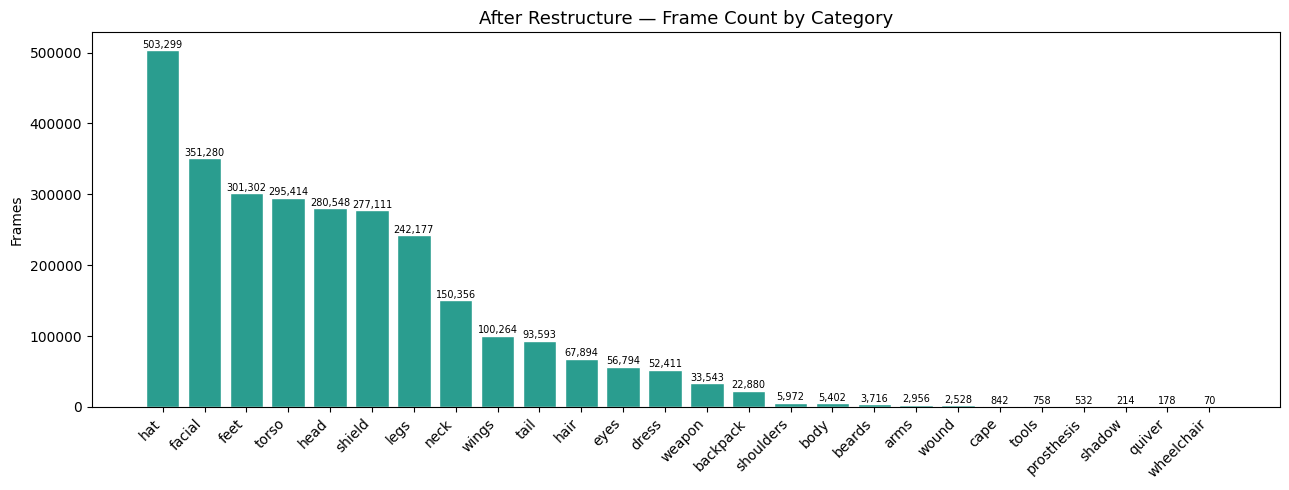

In [19]:
# 재구성 후 분포 시각화
cats_after  = list(result.keys())
cnts_after  = list(result.values())
order = sorted(range(len(cnts_after)), key=lambda i: -cnts_after[i])
cats_after  = [cats_after[i] for i in order]
cnts_after  = [cnts_after[i] for i in order]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(cats_after, cnts_after, color='#2a9d8f', edgecolor='white')
ax.set_title('After Restructure — Frame Count by Category', fontsize=13)
ax.set_ylabel('Frames')
ax.set_xticks(range(len(cats_after)))
ax.set_xticklabels(cats_after, rotation=45, ha='right')
for bar, v in zip(bars, cnts_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{v:,}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

In [20]:
# body 내부 세부 확인
body_sub = Counter(f.stem.split('_')[1]
                   for f in BODY_DIR.glob('*.png')
                   if f.stem.startswith('bodies_'))
print('=== processed/body — bodies 세부 ===')
for k, v in body_sub.most_common():
    print(f'  {k:<12s}  {v:>4,}개')

print()
wing_sub = Counter('_'.join(f.stem.split('_')[1:2])
                   for f in WINGS_DIR.glob('*.png'))
print('=== processed/wings — 종류 ===')
for k, v in wing_sub.most_common():
    print(f'  {k:<12s}  {v:>6,}개')

print()
tail_sub = Counter('_'.join(f.stem.split('_')[1:2])
                   for f in TAIL_DIR.glob('*.png'))
print('=== processed/tail — 종류 ===')
for k, v in tail_sub.most_common():
    print(f'  {k:<12s}  {v:>6,}개')

=== processed/body — bodies 세부 ===
  teen           352개
  female         352개
  male           352개
  pregnant       276개
  muscular       198개
  child          106개

=== processed/wings — 종류 ===
  bat           28,864개
  feathered     17,754개
  monarch       15,130개
  lizard        12,648개
  dragonfly     10,382개
  pixie         10,324개
  lunar          5,162개

=== processed/tail — 종류 ===
  lizard        23,732개
  fluffy        23,463개
  cat           23,265개
  wolf          23,133개


## 5. wound 분리

In [21]:
WOUND_DIR = PROCESSED / 'wound'

to_wound = [f for f in BODY_DIR.glob('*.png') if f.stem.startswith('wound_')]
print(f'processed/body  총 파일 : {len(list(BODY_DIR.glob("*.png"))):,}개')
print(f'wound 이동 대상         : {len(to_wound):,}개')

# 파일명 패턴 확인
wound_sub = Counter('_'.join(f.stem.split('_')[1:2]) for f in to_wound)
print('\n=== wound 종류 ===')
for k, v in wound_sub.most_common():
    print(f'  {k:<20s}  {v:>5,}개')

processed/body  총 파일 : 5,402개
wound 이동 대상         : 2,528개

=== wound 종류 ===
  brain                   704개
  eye                     694개
  mouth                   518개
  arm                     344개
  ribs                    268개


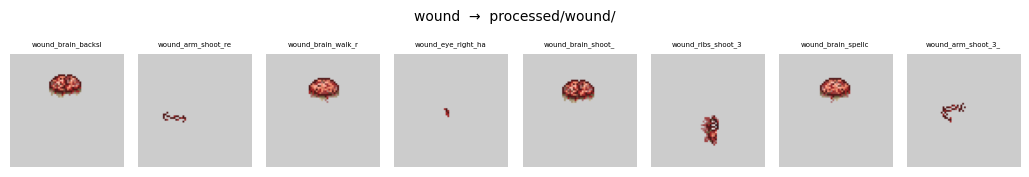

In [22]:
show_samples(to_wound, 'wound  →  processed/wound/', n=8)

In [23]:
WOUND_DIR.mkdir(parents=True, exist_ok=True)

for f in to_wound:
    f.rename(WOUND_DIR / f.name)

print(f'wound 이동 완료: {len(to_wound):,}개 → {WOUND_DIR}')
print(f'processed/body 잔여: {len(list(BODY_DIR.glob("*.png"))):,}개')

wound 이동 완료: 2,528개 → dataset/processed/wound
processed/body 잔여: 2,874개


In [24]:
# 최종 카테고리별 파일 수
result_final = {}
for cat_dir in sorted(PROCESSED.iterdir()):
    if cat_dir.is_dir():
        cnt = sum(1 for _ in cat_dir.rglob('*.png'))
        result_final[cat_dir.name] = cnt

total = sum(result_final.values())
print(f'전체 프레임: {total:,}개\n')
for cat, cnt in sorted(result_final.items(), key=lambda x: -x[1]):
    marker = ' ← wound 분리' if cat == 'wound' else ''
    print(f'  {cat:<12s}  {cnt:>8,}개{marker}')

전체 프레임: 2,849,506개

  hat            503,299개
  facial         351,280개
  feet           301,302개
  torso          295,414개
  head           280,548개
  shield         277,111개
  legs           242,177개
  neck           150,356개
  wings          100,264개
  tail            93,593개
  hair            67,894개
  eyes            56,794개
  dress           52,411개
  weapon          33,543개
  backpack        22,880개
  shoulders        5,972개
  beards           3,716개
  arms             2,956개
  body             2,874개
  wound            2,528개 ← wound 분리
  cape               842개
  tools              758개
  prosthesis         532개
  shadow             214개
  quiver             178개
  wheelchair          70개


## 6. wheelchair / prosthesis 분리

wheelchair 이동 대상 : 70개
prosthesis 이동 대상 : 532개


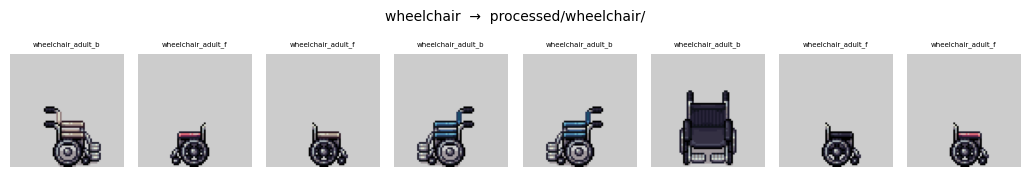

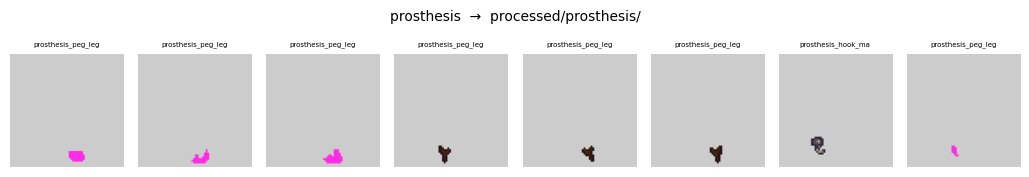

In [25]:
WHEELCHAIR_DIR  = PROCESSED / 'wheelchair'
PROSTHESIS_DIR  = PROCESSED / 'prosthesis'

to_wheelchair = [f for f in BODY_DIR.glob('*.png') if f.stem.startswith('wheelchair_')]
to_prosthesis = [f for f in BODY_DIR.glob('*.png') if f.stem.startswith('prosthesis_')]

print(f'wheelchair 이동 대상 : {len(to_wheelchair):,}개')
print(f'prosthesis 이동 대상 : {len(to_prosthesis):,}개')

show_samples(to_wheelchair, 'wheelchair  →  processed/wheelchair/', n=min(8, len(to_wheelchair)))
show_samples(to_prosthesis, 'prosthesis  →  processed/prosthesis/', n=8)

In [26]:
for target_dir, file_list, label in [
    (WHEELCHAIR_DIR, to_wheelchair, 'wheelchair'),
    (PROSTHESIS_DIR, to_prosthesis, 'prosthesis'),
]:
    target_dir.mkdir(parents=True, exist_ok=True)
    for f in file_list:
        f.rename(target_dir / f.name)
    print(f'{label} 이동 완료: {len(file_list):,}개 → {target_dir}')

print(f'\nprocessed/body 잔여: {len(list(BODY_DIR.glob("*.png"))):,}개')

wheelchair 이동 완료: 70개 → dataset/processed/wheelchair
prosthesis 이동 완료: 532개 → dataset/processed/prosthesis

processed/body 잔여: 2,272개


In [27]:
# 최종 카테고리별 파일 수
result_final = {}
for cat_dir in sorted(PROCESSED.iterdir()):
    if cat_dir.is_dir():
        result_final[cat_dir.name] = sum(1 for _ in cat_dir.rglob('*.png'))

total = sum(result_final.values())
print(f'전체 프레임: {total:,}개\n')
for cat, cnt in sorted(result_final.items(), key=lambda x: -x[1]):
    print(f'  {cat:<14s}  {cnt:>8,}개')

전체 프레임: 2,848,904개

  hat              503,299개
  facial           351,280개
  feet             301,302개
  torso            295,414개
  head             280,548개
  shield           277,111개
  legs             242,177개
  neck             150,356개
  wings            100,264개
  tail              93,593개
  hair              67,894개
  eyes              56,794개
  dress             52,411개
  weapon            33,543개
  backpack          22,880개
  shoulders          5,972개
  beards             3,716개
  arms               2,956개
  wound              2,528개
  body               2,272개
  cape                 842개
  tools                758개
  prosthesis           532개
  shadow               214개
  quiver               178개
  wheelchair            70개
